# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, val_bpb, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 84
Columns: ['commit', 'val_bpb', 'memory_gb', 'status', 'description']


,commit,val_bpb,memory_gb,status,description
0,46294df,1.228006,1.7,KEEP,baseline
1,70a4278,1.227179,1.7,DISCARD,torch.compile on Linux: no throughput gain (sa...
2,0bb1b3c,1.028962,1.4,KEEP,DEPTH=6: 36 steps 18.9M tokens 42K tok/sec
3,0bb1b3c,0.794208,2.3,KEEP,DEPTH=4 (--depth 4): 62 steps 32.5M tokens 89K...
4,3bb451d,0.777060,2.3,KEEP,WARMDOWN_RATIO 0.5->0.3: GPU0 result
5,3bb451d,0.775165,2.3,KEEP,WARMDOWN_RATIO 0.5->0.3: GPU1 result (best)
6,cb6bd98,0.769305,2.3,KEEP,WARMDOWN=0.2 DEPTH=4 GPU0
7,cb6bd98,0.757124,2.2,KEEP,WARMDOWN=0.2 DEPTH=3 GPU1 (new best)
8,c4f7175,0.751611,2.2,KEEP,WARMDOWN=0.1 DEPTH=3 GPU0
9,c4f7175,0.707381,2.1,KEEP,WARMDOWN=0.1 DEPTH=2 GPU1 (best: 137 steps)


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    47
KEEP       37

Keep rate: 37/84 = 44.0%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["val_bpb"]
    desc = row["description"]
    print(f"  #{i:3d}  bpb={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (37 total):

  #  0  bpb=1.228006  mem=1.7GB  baseline
  #  2  bpb=1.028962  mem=1.4GB  DEPTH=6: 36 steps 18.9M tokens 42K tok/sec
  #  3  bpb=0.794208  mem=2.3GB  DEPTH=4 (--depth 4): 62 steps 32.5M tokens 89K tok/sec
  #  4  bpb=0.777060  mem=2.3GB  WARMDOWN_RATIO 0.5->0.3: GPU0 result
  #  5  bpb=0.775165  mem=2.3GB  WARMDOWN_RATIO 0.5->0.3: GPU1 result (best)
  #  6  bpb=0.769305  mem=2.3GB  WARMDOWN=0.2 DEPTH=4 GPU0
  #  7  bpb=0.757124  mem=2.2GB  WARMDOWN=0.2 DEPTH=3 GPU1 (new best)
  #  8  bpb=0.751611  mem=2.2GB  WARMDOWN=0.1 DEPTH=3 GPU0
  #  9  bpb=0.707381  mem=2.1GB  WARMDOWN=0.1 DEPTH=2 GPU1 (best: 137 steps)
  # 10  bpb=0.704718  mem=8.2GB  DEPTH=2 WARMDOWN=0.1 batch=32 GPU0 (after ollama stop)
  # 11  bpb=0.701946  mem=8.2GB  DEPTH=2 WARMDOWN=0.1 batch=32 GPU1 (new best: 141 steps 227K t/s)
  # 17  bpb=0.697069  mem=8.2GB  MATRIX_LR=0.06 GPU1 (141 steps, new best)
  # 19  bpb=0.677509  mem=8.4GB  ASPECT_RATIO=128 n_embd=256 LR=0.06 GPU1 (96 steps 50M to

## Val BPB Over Time

Track how the best (kept) val_bpb evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

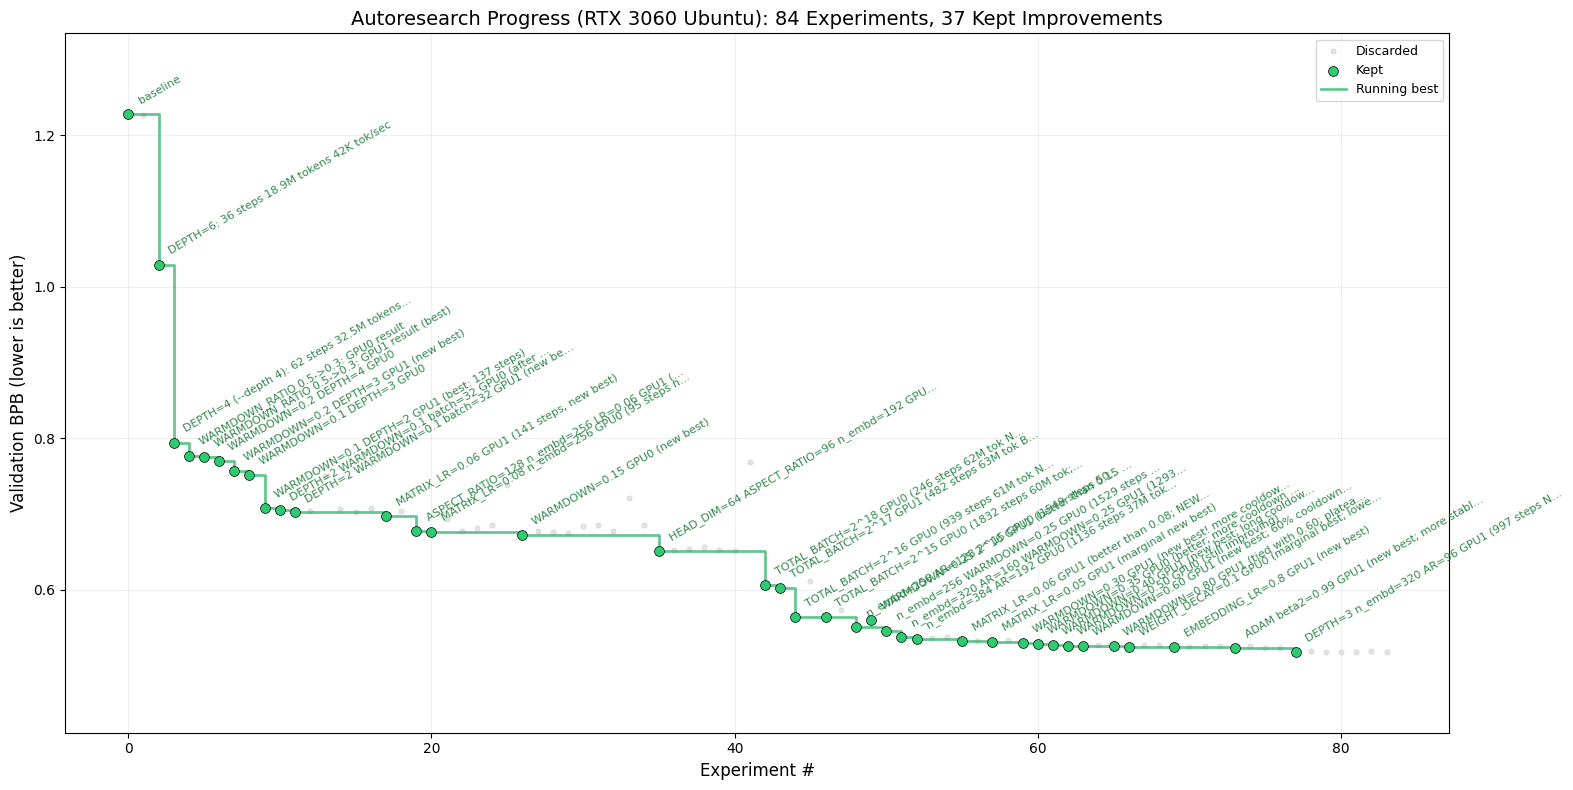

Saved to progress.png


In [7]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "val_bpb"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["val_bpb"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["val_bpb"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["val_bpb"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "val_bpb"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress (RTX 3060 Ubuntu): {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
best_bpb = kept_bpb.min()
margin = (baseline_bpb - best_bpb) * 0.15
ax.set_ylim(best_bpb - margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = kept["val_bpb"].min()
best_row = kept.loc[kept["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['val_bpb']:.6f}  {desc}")

Baseline val_bpb:  1.228006
Best val_bpb:      0.517530
Total improvement: 0.710476 (57.86%)
Best experiment:   DEPTH=3 n_embd=320 AR=96 GPU1 (997 steps NEW BEST)

Cumulative effort per improvement:
  Experiment #  0: bpb=1.228006  baseline
  Experiment #  2: bpb=1.028962  DEPTH=6: 36 steps 18.9M tokens 42K tok/sec
  Experiment #  3: bpb=0.794208  DEPTH=4 (--depth 4): 62 steps 32.5M tokens 89K tok/sec
  Experiment #  4: bpb=0.777060  WARMDOWN_RATIO 0.5->0.3: GPU0 result
  Experiment #  5: bpb=0.775165  WARMDOWN_RATIO 0.5->0.3: GPU1 result (best)
  Experiment #  6: bpb=0.769305  WARMDOWN=0.2 DEPTH=4 GPU0
  Experiment #  7: bpb=0.757124  WARMDOWN=0.2 DEPTH=3 GPU1 (new best)
  Experiment #  8: bpb=0.751611  WARMDOWN=0.1 DEPTH=3 GPU0
  Experiment #  9: bpb=0.707381  WARMDOWN=0.1 DEPTH=2 GPU1 (best: 137 steps)
  Experiment # 10: bpb=0.704718  DEPTH=2 WARMDOWN=0.1 batch=32 GPU0 (after ollama stop)
  Experiment # 11: bpb=0.701946  DEPTH=2 WARMDOWN=0.1 batch=32 GPU1 (new best: 141 steps 227K t

## Top Hits (Kept Experiments by Improvement)

In [6]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["val_bpb"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["val_bpb"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['val_bpb']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.234754  0.794208  DEPTH=4 (--depth 4): 62 steps 32.5M tokens 89K tok/sec
   2  +0.199044  1.028962  DEPTH=6: 36 steps 18.9M tokens 42K tok/sec
   3  +0.044350  0.606253  TOTAL_BATCH=2^18 GPU0 (246 steps 62M tok NEW BEST)
   4  +0.044230  0.707381  WARMDOWN=0.1 DEPTH=2 GPU1 (best: 137 steps)
   5  +0.038286  0.563299  TOTAL_BATCH=2^16 GPU0 (939 steps 61M tok NEW BEST)
   6  +0.022109  0.650603  HEAD_DIM=64 ASPECT_RATIO=96 n_embd=192 GPU1 (129 steps NEW BEST)
   7  +0.019560  0.677509  ASPECT_RATIO=128 n_embd=256 LR=0.06 GPU1 (96 steps 50M tok NEW BEST)
   8  +0.017148  0.777060  WARMDOWN_RATIO 0.5->0.3: GPU0 result
   9  +0.013975  0.545657  n_embd=256 WARMDOWN=0.25 GPU0 (1529 steps new best)
  10  +0.012484  0.550721  n_embd=256 AR=128 2^15 GPU0 (1549 steps 50M tok NEW BEST)
  11  +0.012181  0.757124  WARMDOWN=0.2 DEPTH=3 GPU1 (new best)
  12  +0.008203  0.5